In [2]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors

from matplotlib.axes import Axes
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FixedLocator, NullLocator)
from collections import Counter

from hubo_qaoa.utils.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [18]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingall.precompute.0.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)
list(res.keys())

['test_N2_W2',
 'trivial',
 'test_N3_W4',
 'test_N4_W5',
 'test_N7_W2',
 'test_N7_W3',
 'test_N7_W4',
 'test_N8_W2',
 'test_N8_W3',
 'test_N8_W5',
 'test_N8_W6']

In [7]:
def plot(ax, filename, maxdb, maxdg, shots, show_cbar=False):
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.shots{shots}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    delta_b_fixed = res['delta_b_fixed'] 
    delta_g_fixed = res['delta_g_fixed'] 
    rescaling = np.array(res['rescaling'])
    ps = np.array(res['ps'])
    print(np.min(energies))
    
    def log_edges(x):
        return np.concatenate([
            x[:1] / np.sqrt(x[1] / x[0]),
            np.sqrt(x[:-1] * x[1:]),
            x[-1:] * np.sqrt(x[-1] / x[-2])
        ])

    ps_edges = log_edges(ps)
    rescaling_edges = log_edges(rescaling)
    
    cmap = plt.get_cmap()
    cmap.set_over('white')
    
    im = ax.pcolormesh(
        ps_edges,
        rescaling_edges,
        energies.T,      # transpose so shape is (Ny, Nx)
        shading='auto',
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    ax.set_xscale('log')
    xticks = sorted(set(int(x) for x in np.logspace(0, 2.25, 4, base=10)))
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks])
    ax.xaxis.set_minor_locator(NullLocator())

    ax.set_yscale('log')

    ax.set_xlabel('p')
    # ax.set_ylabel('rescaling')

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.set_label('Energy')

    
    ax.set_ylabel(r'$\Delta_\beta / \Delta_{\beta,\text{fixed}} = \Delta_\gamma / \Delta_{\gamma,\text{fixed}}$')
    ax.set_title(f'{filename}, $\\Delta_\\beta = {delta_b_fixed}$, $\\Delta_\\gamma = {delta_g_fixed}$')
    return ax

0.0
0.0
0.0
0.0
0.0
-7.105427357601002e-15


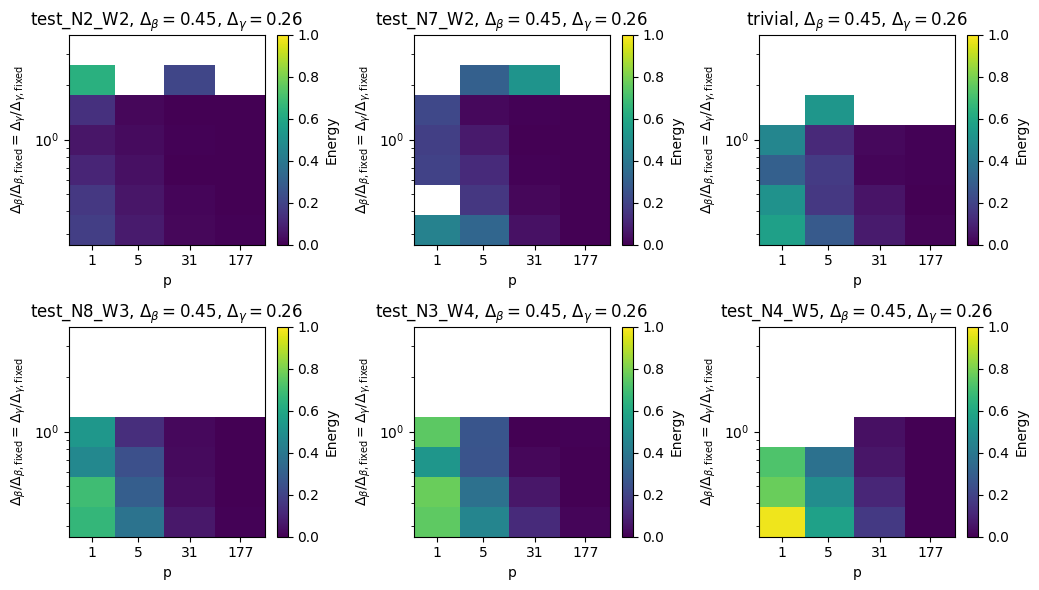

In [13]:
fig, axs = plt.subplots(2, 3)
plot(axs[0, 0], 'test_N2_W2', 0.45, 0.26, 4000, True)
plot(axs[0, 1], 'test_N7_W2', 0.45, 0.26, 4000, True)
plot(axs[0, 2], 'trivial', 0.45, 0.26, 4000, True)
plot(axs[1, 0], 'test_N8_W3', 0.45, 0.26, 4000, True)
plot(axs[1, 1], 'test_N3_W4', 0.45, 0.26, 4000, True)
plot(axs[1, 2], 'test_N4_W5', 0.45, 0.26, 4000, True)

fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [9]:
def plot_dist(
    axs: list[Axes], 
    filename, copy_numbers, maxdb, maxdg, shots,
    p = 6, db = 0.1, dg = 4.0,
    normalise=True
) -> list[Axes]:
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
    hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.shots{shots}.pkl', 'rb') as f:
        res = pickle.load(f)
        
    
    samples_dict: dict[tuple, str] = res['samples_dict']
    energies = res['energies']
    delta_b_fixed = res['delta_b_fixed'] 
    delta_g_fixed = res['delta_g_fixed']
    iters = ['0', '5', '9']
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    
    keys = samples_dict.keys()
    true_key = None
    for key in keys:
        if key[0] == p and np.abs(key[1] * db - delta_b_fixed)**2 < 0.005 and np.abs(key[1] * dg - delta_g_fixed)**2 < 0.005:
            true_key = key
            break
    if true_key is None:
        raise Exception('Could not find key')
    print(filename, true_key)

    cutoff=25
    ax = axs[0]
    random_samples = np.random.choice(('0', '1'), (shots, n*T))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(norm * (evaluate_sparse_pauli_samples(rand_samples, hamiltonian)), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/shots]*len(rand_vals), rwidth=1, log=True)
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = -1', ha='right', va='top', transform=ax.transAxes)
    
    for i in range(1, len(axs)):
        ax = axs[i]
        counter = Counter(samples_dict[true_key][i-1])
        
        evals = np.round(norm * (evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian)), 2)
        energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
        sample_vals = np.array([x for xs in energies for x in xs])

        ax.hist(sample_vals, bins=range(cutoff+1), weights=[1/shots]*len(sample_vals), rwidth=1, log=True)
        ax.set_xlim(0, cutoff)
        ax.set_ylim(10**-3, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]}', ha='right', va='top', transform=ax.transAxes)

    return axs

Keeping constraints at times: [0]
test_N2_W2 (5, np.float64(1.0))
Keeping constraints at times: [0]
test_N7_W2 (5, np.float64(1.0))
Keeping constraints at times: [1 0]
trivial (5, np.float64(1.0))
Keeping constraints at times: [0 1]
test_N8_W3 (5, np.float64(1.0))
Keeping constraints at times: [0 1 2]
test_N3_W4 (5, np.float64(1.0))
Keeping constraints at times: [0 2 3 1]
test_N4_W5 (5, np.float64(1.0))


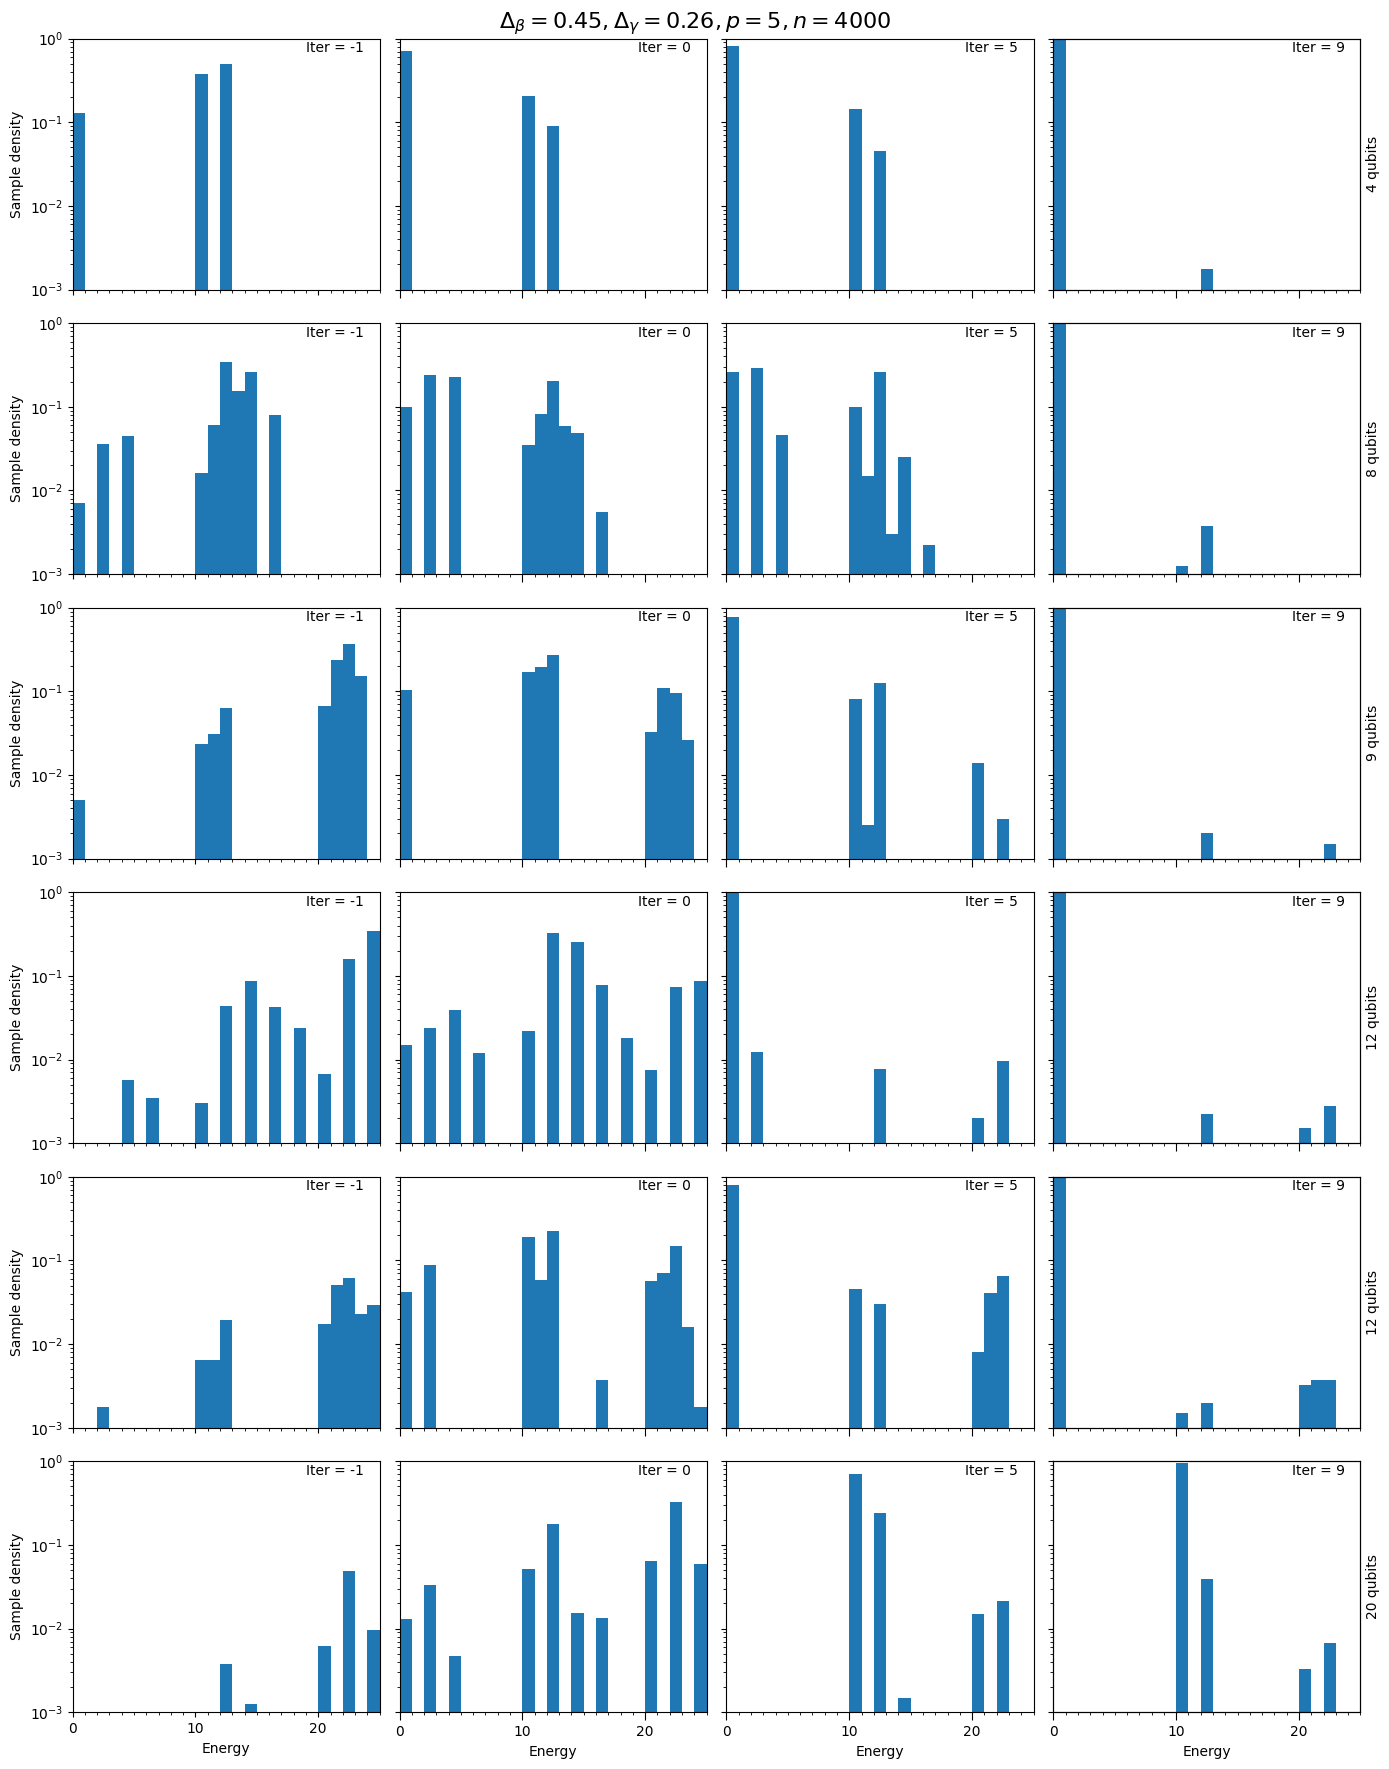

In [ ]:
fig, axs = plt.subplots(6, 4, sharey='row', sharex='col')
p = 5
db = 0.45
dg = 0.26
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]
axs5 = axs[5, :]


axs0 = plot_dist(axs0, 'test_N2_W2', [1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs1 = plot_dist(axs1, 'test_N7_W2', [1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs2 = plot_dist(axs2, 'trivial', [1,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs3 = plot_dist(axs3, 'test_N8_W3', [1,1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs4 = plot_dist(axs4, 'test_N3_W4', [2,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs5 = plot_dist(axs5, 'test_N4_W5', [2,1,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [4, 8, 9, 12, 12, 15]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {db}, \\Delta_\\gamma = {dg}, p = {p}, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()
# fig.set_tight_layout('tight')


Keeping constraints at times: [0]
test_N2_W2 (31, np.float64(1.0))
Keeping constraints at times: [0]
test_N7_W2 (31, np.float64(1.0))
Keeping constraints at times: [1 0]
trivial (31, np.float64(1.0))
Keeping constraints at times: [1 0]
test_N8_W3 (31, np.float64(1.0))
Keeping constraints at times: [2 0 1]
test_N3_W4 (31, np.float64(1.0))
Keeping constraints at times: [2 3 0 1]
test_N4_W5 (31, np.float64(1.0))


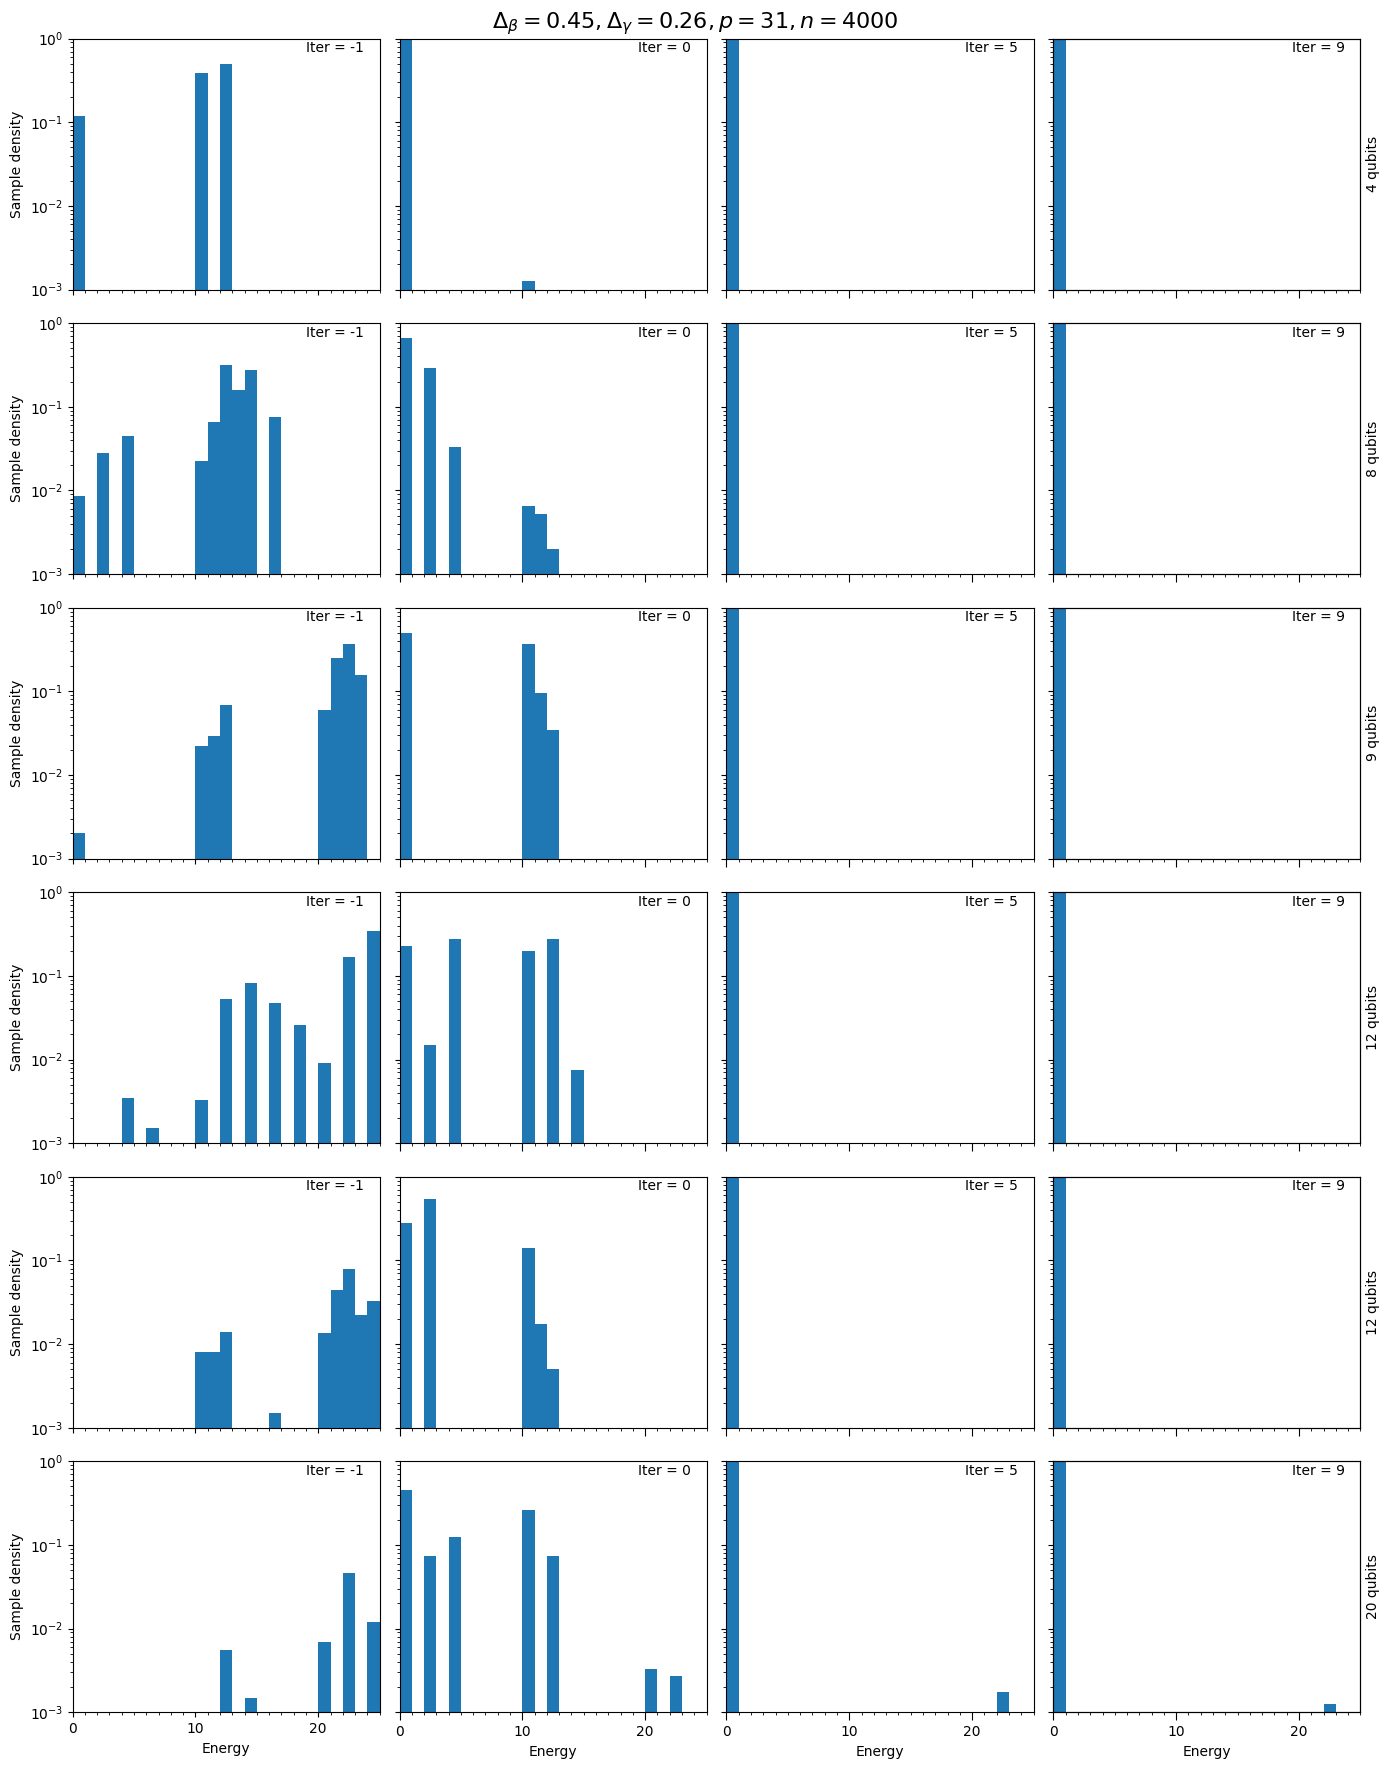

In [ ]:
fig, axs = plt.subplots(6, 4, sharey='row', sharex='col')
p = 31
db = 0.45
dg = 0.26
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]
axs5 = axs[5, :]


axs0 = plot_dist(axs0, 'test_N2_W2', [1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs1 = plot_dist(axs1, 'test_N7_W2', [1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs2 = plot_dist(axs2, 'trivial', [1,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs3 = plot_dist(axs3, 'test_N8_W3', [1,1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs4 = plot_dist(axs4, 'test_N3_W4', [2,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs5 = plot_dist(axs5, 'test_N4_W5', [2,1,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [4, 8, 9, 12, 12, 15]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {db}, \\Delta_\\gamma = {dg}, p = {p}, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()
# fig.set_tight_layout('tight')


In [15]:
2**20

1048576